# Seaborn Tutorial — Step by Step
### Data Visualization — Hindi Comments ke Saath
---
**Yeh notebook run karne ke liye:** Upar `Run All` ya har cell ke baad `Shift + Enter` dabao

**Kya seekhoge:**
- `histplot` — distribution
- `boxplot` — spread & outliers
- `scatterplot` — 2 variables ka relation
- `heatmap` — correlation
- `lineplot` — trend
- `barplot` — category comparison


## Step 1: Libraries Install Karo
*(Agar pehle se installed hain toh yeh cell skip kar sakte ho)*

In [1]:
# Agar install nahi hain toh yeh run karo
# !pip install seaborn matplotlib pandas numpy

## Step 2: Libraries Import Karo

In [2]:
import seaborn as sns           # charts banane ke liye
import matplotlib.pyplot as plt   # chart dikhane ke liye
import pandas as pd               # data table ke liye
import numpy as np                # numbers ke liye

# Seaborn ka style set karo
# Options: "whitegrid", "darkgrid", "white", "dark", "ticks"
sns.set_theme(style="whitegrid", palette="muted")

print("Libraries ready hain!")

Libraries ready hain!


## Step 3: Sample Data Banao
Hum ek school ka fake data use karenge — 30 students ke marks, study hours, gender aur class.

> **Apna data use karna ho toh:** `pd.read_csv('aapki_file.csv')` use karo

In [3]:
np.random.seed(42)  # data har baar same rahe isliye

data = pd.DataFrame({
    'student_id':     range(1, 31),
    'study_hours':    np.random.randint(1, 10, 30),
    'math_marks':     np.random.randint(40, 100, 30),
    'science_marks':  np.random.randint(35, 100, 30),
    'english_marks':  np.random.randint(45, 98, 30),
    'gender':         np.random.choice(['Male', 'Female'], 30),
    'class':          np.random.choice(['10A', '10B', '10C'], 30)
})

print(f"Data ready! Kul rows: {len(data)}")
data.head()  # pehli 5 rows dikhao

Data ready! Kul rows: 30


,student_id,study_hours,math_marks,science_marks,english_marks,gender,class
0,1,7,90,38,95,Male,10C
1,2,4,46,36,61,Female,10A
2,3,8,60,40,52,Male,10C
3,4,5,48,88,79,Male,10C
4,5,7,78,38,79,Male,10A


---
## Chart 1: `histplot` — Distribution Dekhna
**Kab use karein:** Jab dekhna ho ki ek column ki values kaise distribute hain
- Zyada students ko kitne marks mile?
- Salary/age/price ka spread kaisa hai?

**Boxplot se fark:** Histplot *exact counts* dikhata hai, boxplot *summary* dikhata hai

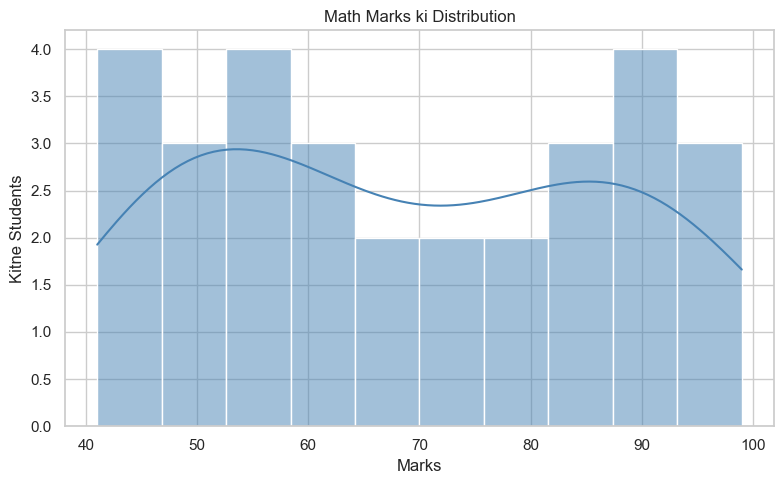

In [4]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=data,         # DataFrame
    x='math_marks',    # kaunsa column
    bins=10,           # kitne groups (bars)
    color='steelblue',
    kde=True           # smooth curve bhi dikhao
)

plt.title('Math Marks ki Distribution')
plt.xlabel('Marks')
plt.ylabel('Kitne Students')
plt.tight_layout()
plt.show()

---
## Chart 2: `boxplot` — Spread & Outliers Dekhna
**Kab use karein:** Jab groups ke beech marks/values ka spread compare karna ho

**Boxplot padhna:**
- Beech ki line = **median** (50% students ke marks yahan hain)
- Box = **25% se 75%** students (middle 50%)
- Whiskers (lines bahar) = baaki normal range
- **Dots bahar = outliers** (unusual values)

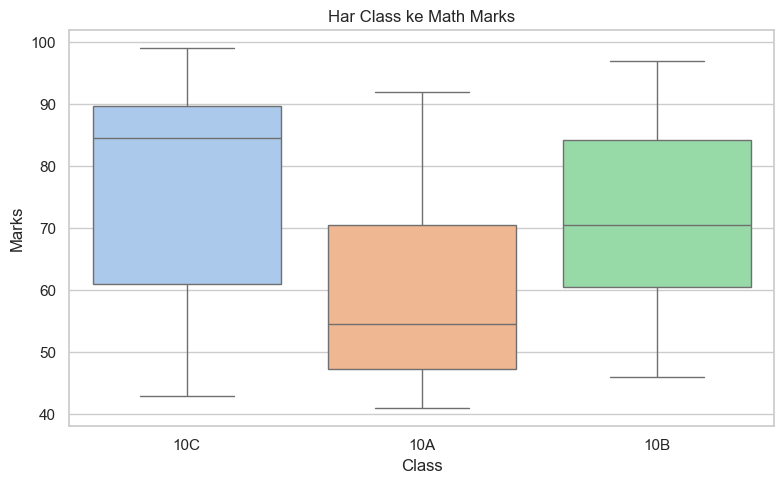

In [5]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=data,
    x='class',          # x-axis = categories
    y='math_marks',     # y-axis = values
    hue='class',        # har class ka alag rang
    palette='pastel',
    legend=False
)

plt.title('Har Class ke Math Marks')
plt.xlabel('Class')
plt.ylabel('Marks')
plt.tight_layout()
plt.show()

---
## Chart 3: `scatterplot` — 2 Variables ka Relation
**Kab use karein:** Jab dekhna ho ki kya 2 cheezein related hain
- Zyada padhne walon ke marks zyada hain ya nahi?
- Height aur weight ka relation?

**Trend line** bhi add kar sakte hain `regplot` se

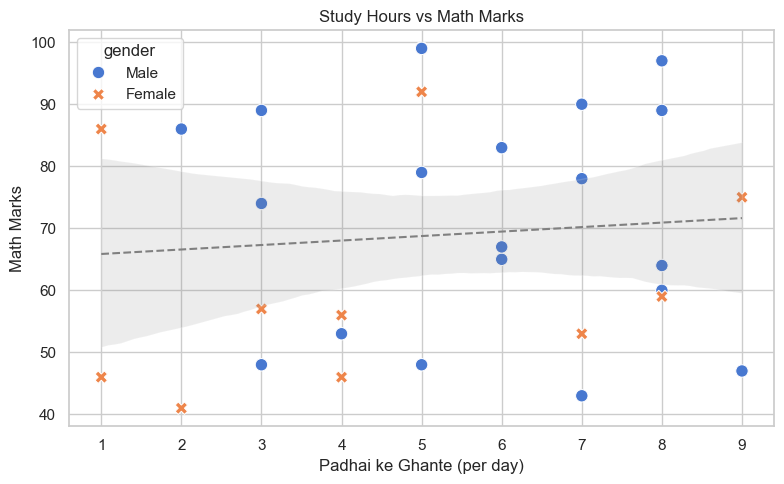

In [6]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=data,
    x='study_hours',   # x-axis
    y='math_marks',    # y-axis
    hue='gender',      # rang = gender
    style='gender',    # shape bhi alag (accessibility)
    s=80               # dot ka size
)

# Trend line add karo (sirf line, dots nahi)
sns.regplot(
    data=data,
    x='study_hours',
    y='math_marks',
    scatter=False,
    color='gray',
    line_kws={'linestyle': '--', 'linewidth': 1.5}
)

plt.title('Study Hours vs Math Marks')
plt.xlabel('Padhai ke Ghante (per day)')
plt.ylabel('Math Marks')
plt.tight_layout()
plt.show()

---
## Chart 4: `heatmap` — Correlation Dekhna
**Kab use karein:** Jab multiple columns ke beech relation ek saath dekhna ho

**Numbers padhna:**
- `+1.0` = perfect positive relation (dono saath badhte hain)
- `-1.0` = perfect negative relation (ek badhta hai to doosra ghatta hai)
- `0.0` = koi relation nahi

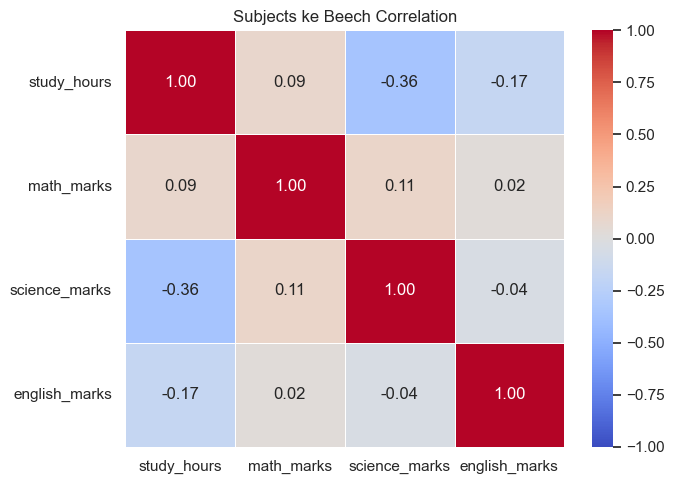

Correlation Table:
               study_hours  math_marks  science_marks  english_marks
study_hours           1.00        0.09          -0.36          -0.17
math_marks            0.09        1.00           0.11           0.02
science_marks        -0.36        0.11           1.00          -0.04
english_marks        -0.17        0.02          -0.04           1.00


In [7]:
# Pehle sirf numeric columns lo aur correlation calculate karo
numeric_cols = data[['study_hours', 'math_marks', 'science_marks', 'english_marks']]
correlation = numeric_cols.corr()

plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation,
    annot=True,      # numbers dikhao andar
    fmt='.2f',       # 2 decimal places
    cmap='coolwarm', # blue = negative, red = positive
    vmin=-1, vmax=1,
    linewidths=0.5
)

plt.title('Subjects ke Beech Correlation')
plt.tight_layout()
plt.show()

print("Correlation Table:")
print(correlation.round(2))

---
## Chart 5: `lineplot` — Trend Dekhna
**Kab use karein:** Jab time ke saath ya sequence mein change dekhna ho
- Monthly sales ka trend
- Study hours badhne par marks ka change

**Bar chart se fark:** Lineplot *continuous change* dikhata hai, bar chart *separate values* dikhata hai

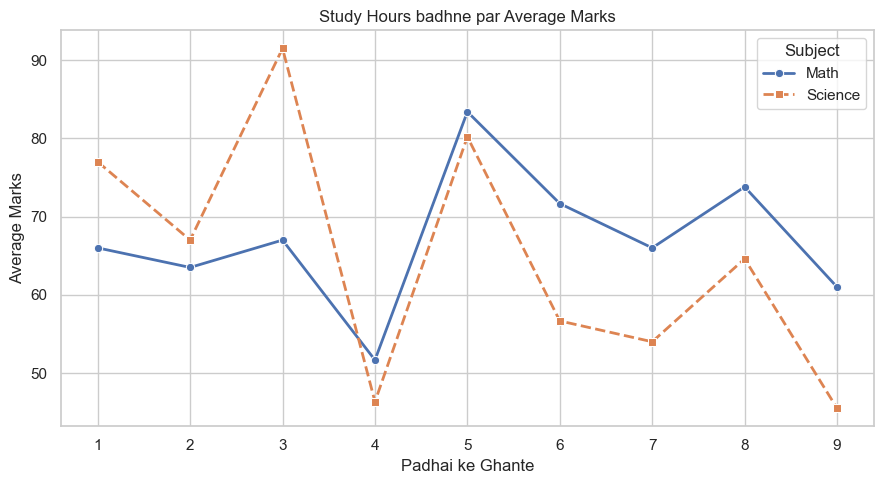

In [8]:
# Study hours ke hisaab se average marks nikalo
hourly_avg = data.groupby('study_hours')[['math_marks', 'science_marks']].mean().reset_index()

plt.figure(figsize=(9, 5))

sns.lineplot(
    data=hourly_avg,
    x='study_hours',
    y='math_marks',
    label='Math',
    marker='o',       # har point pe circle
    color='#4C72B0',
    linewidth=2
)

sns.lineplot(
    data=hourly_avg,
    x='study_hours',
    y='science_marks',
    label='Science',
    marker='s',        # square marker
    color='#DD8452',
    linewidth=2,
    linestyle='--'     # dashed line — dono lines alag dikhein
)

plt.title('Study Hours badhne par Average Marks')
plt.xlabel('Padhai ke Ghante')
plt.ylabel('Average Marks')
plt.legend(title='Subject')
plt.tight_layout()
plt.show()

---
## Chart 6: `barplot` — Category Comparison
**Kab use karein:** Jab categories ka average compare karna ho
- Male vs Female ke average marks
- City-wise average salary

**Histplot se fark:** Barplot *categories compare* karta hai, histplot *ek column ka spread* dikhata hai

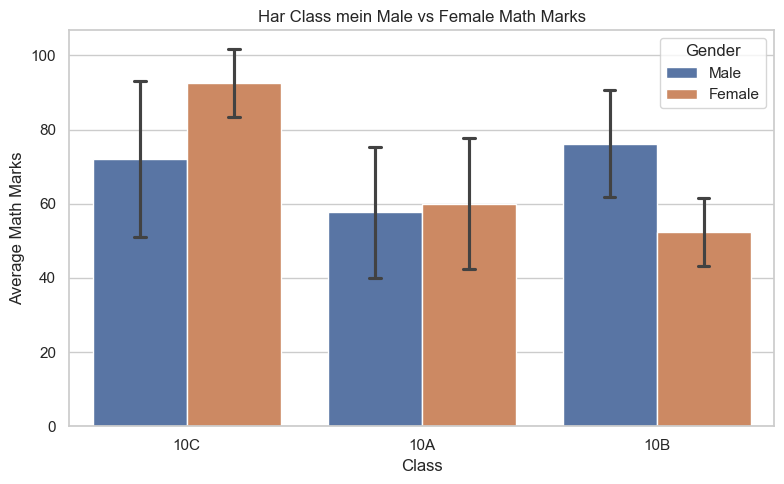

In [9]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=data,
    x='class',
    y='math_marks',
    hue='gender',
    palette={'Male': '#4C72B0', 'Female': '#DD8452'},
    errorbar='sd',   # error bar = standard deviation
    capsize=0.1
)

plt.title('Har Class mein Male vs Female Math Marks')
plt.xlabel('Class')
plt.ylabel('Average Math Marks')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

---
## Bonus: Saare Charts Ek Saath (Subplot)
Ek hi figure mein saare 6 charts dikhao — presentations ke liye useful

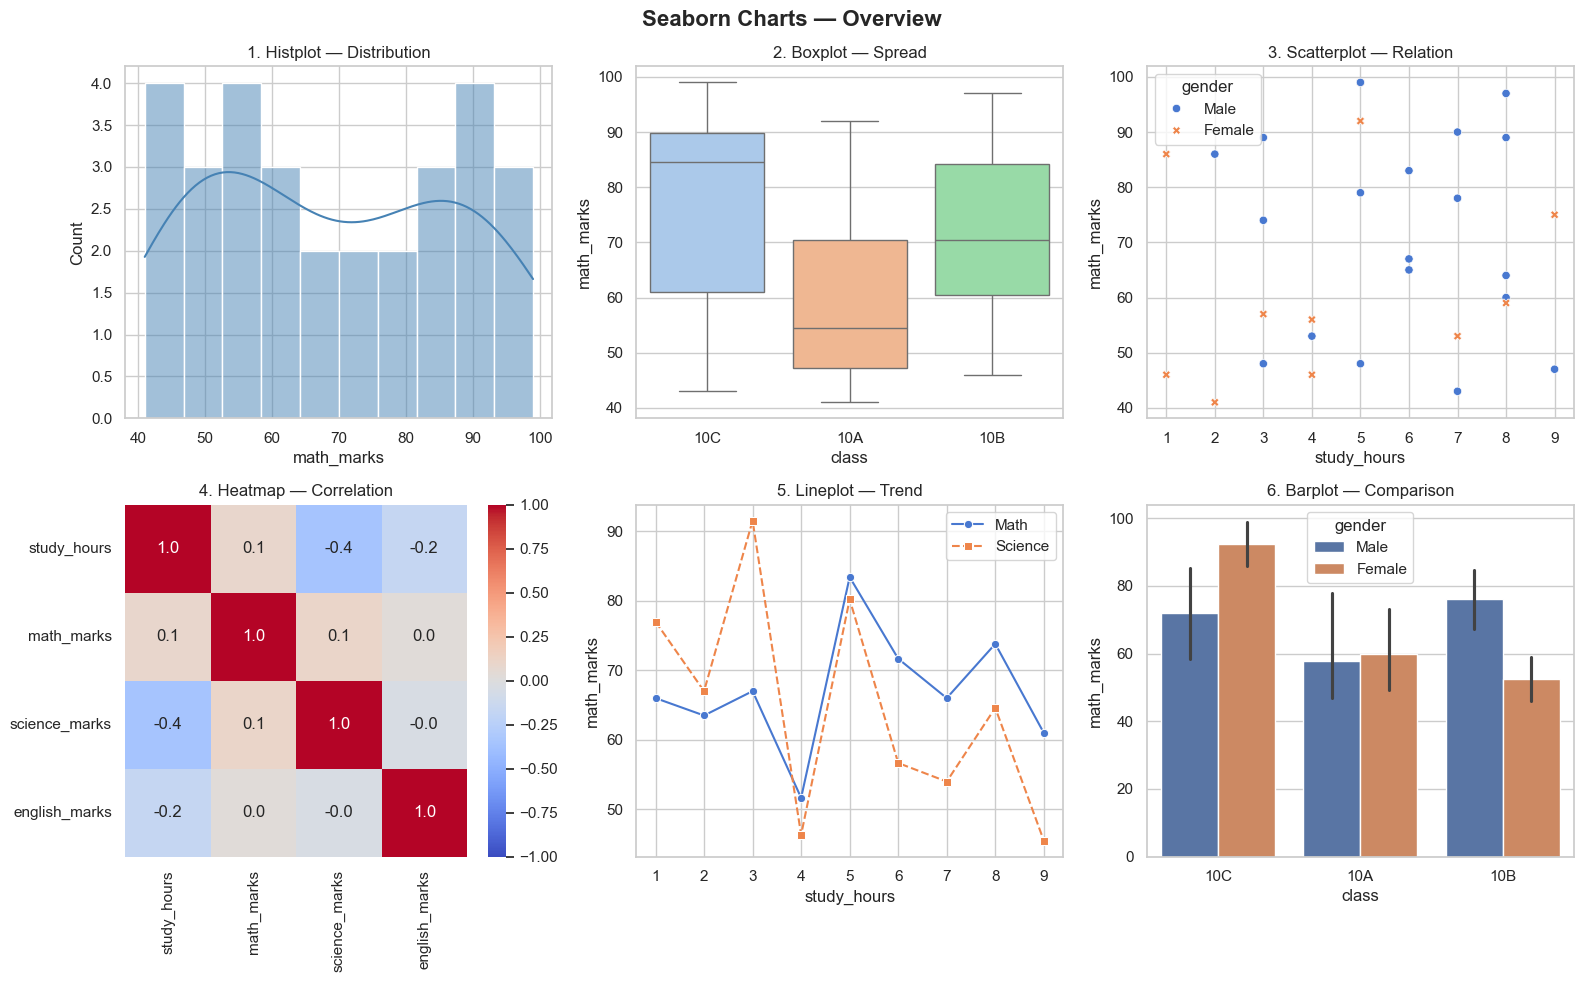

In [10]:
# Yeh do lines Bonus cell ki shuru mein add karo
numeric_cols = data[['study_hours', 'math_marks', 'science_marks', 'english_marks']]
correlation = numeric_cols.corr()
hourly_avg = data.groupby('study_hours')[['math_marks', 'science_marks']].mean().reset_index()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Seaborn Charts — Overview', fontsize=16, fontweight='bold')

sns.histplot(data=data, x='math_marks', bins=10, ax=axes[0,0], color='steelblue', kde=True)
axes[0,0].set_title('1. Histplot — Distribution')

sns.boxplot(data=data, x='class', y='math_marks', palette='pastel',
            hue='class', legend=False, ax=axes[0,1])
axes[0,1].set_title('2. Boxplot — Spread')

sns.scatterplot(data=data, x='study_hours', y='math_marks',
                hue='gender', style='gender', ax=axes[0,2])
axes[0,2].set_title('3. Scatterplot — Relation')

sns.heatmap(correlation, annot=True, fmt='.1f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=axes[1,0])
axes[1,0].set_title('4. Heatmap — Correlation')

sns.lineplot(data=hourly_avg, x='study_hours', y='math_marks',
             label='Math', marker='o', ax=axes[1,1])
sns.lineplot(data=hourly_avg, x='study_hours', y='science_marks',
             label='Science', marker='s', linestyle='--', ax=axes[1,1])
axes[1,1].set_title('5. Lineplot — Trend')

sns.barplot(data=data, x='class', y='math_marks', hue='gender',
            palette={'Male': '#4C72B0', 'Female': '#DD8452'}, ax=axes[1,2])
axes[1,2].set_title('6. Barplot — Comparison')

plt.tight_layout()
plt.show()

---
## Summary: Kab Kaunsa Chart Use Karein

| Chart | Kab Use Karein | Example |
|-------|---------------|---------|
| `histplot` | Ek column ka spread dekhna | Marks ki distribution |
| `boxplot` | Groups ke beech spread compare karna | Class A vs B vs C |
| `scatterplot` | 2 numbers ka relation | Hours vs Marks |
| `heatmap` | Columns ke beech correlation | Subjects ka relation |
| `lineplot` | Time ke saath trend | Monthly sales |
| `barplot` | Categories ka average compare | Male vs Female |

---
### Apna Data Kaise Load Karein

```python
# CSV file se
data = pd.read_csv('aapki_file.csv')

# Excel file se
data = pd.read_excel('aapki_file.xlsx')

# Data dekhne ke liye
data.head()        # pehli 5 rows
data.info()        # columns aur datatypes
data.describe()    # basic statistics
```

**Next Step:** Apna khud ka CSV/Excel file load karo aur yahi charts dobara banao!
